# Explore here

### Paso 1 coleccion de datos

In [5]:

import pandas as pd

# traemos los datos desde la url publica
datos_importados_total = pd.read_csv("https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv", sep=";")

# mostramos el dataset
datos_importados_total.head()



,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
#lo guardamos en local como csv
datos_importados_total.to_csv("../data/raw/todos_datos.csv", index=False)

### Paso 2: exploracion y limpieza de datos

In [8]:
#vemos las dimensiones
datos_importados_total.shape
#mostramos el resumen del dataset
datos_importados_total.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

#### Elimnamos duplicados

In [9]:
# estas columnas las voy a usar como criterio para detectar filas duplicadas,
# es decir, si el valor en estas columnas es igual se elimina porque cuenta como duplicado
cols_clave = ["age", "job", "marital", "education", "campaign", "poutcome"]

# se eliminan los registros con el .drop_duplicates y le metes como subset las columnas clave de antes
datos_importados_total = datos_importados_total.drop_duplicates(subset=cols_clave)
datos_importados_total.shape

(16049, 21)

#### Eliminamos informacion irrelevante

In [10]:
#elimino duration porque segun la documentacion del dataset este valor
#no se conoce antes de realizar la llamada al cliente, por lo tanto no es
#util para un modelo predictivo realista ya que introduce fuga de datos
datos_importados_total.drop(["duration"], axis=1, inplace=True)
datos_importados_total.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Paso 3 Analisis de variables univariadas

#### Analisis de variables categoricas

C:\Users\Marcos\AppData\Local\Temp\ipykernel_21224\617764820.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sns.histplot(ax=axis[0, 0], data=datos_importados_total, x="job").set_xticklabels(axis[0, 0].get_xticklabels(), rotation=45, ha="right")#meto el set_xticklabels porque si no se solapan los trbajos y la education porque hay muchos tipos de trabajo y educacione,que lo que hace es rotar los nombres para que no se solapen
C:\Users\Marcos\AppData\Local\Temp\ipykernel_21224\617764820.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  sns.histplot(ax=axis[0, 2], data=datos_importados_total, x="education").set_xticklabels(axis[0, 2].get_xticklabels(), rotation=45, ha="right")


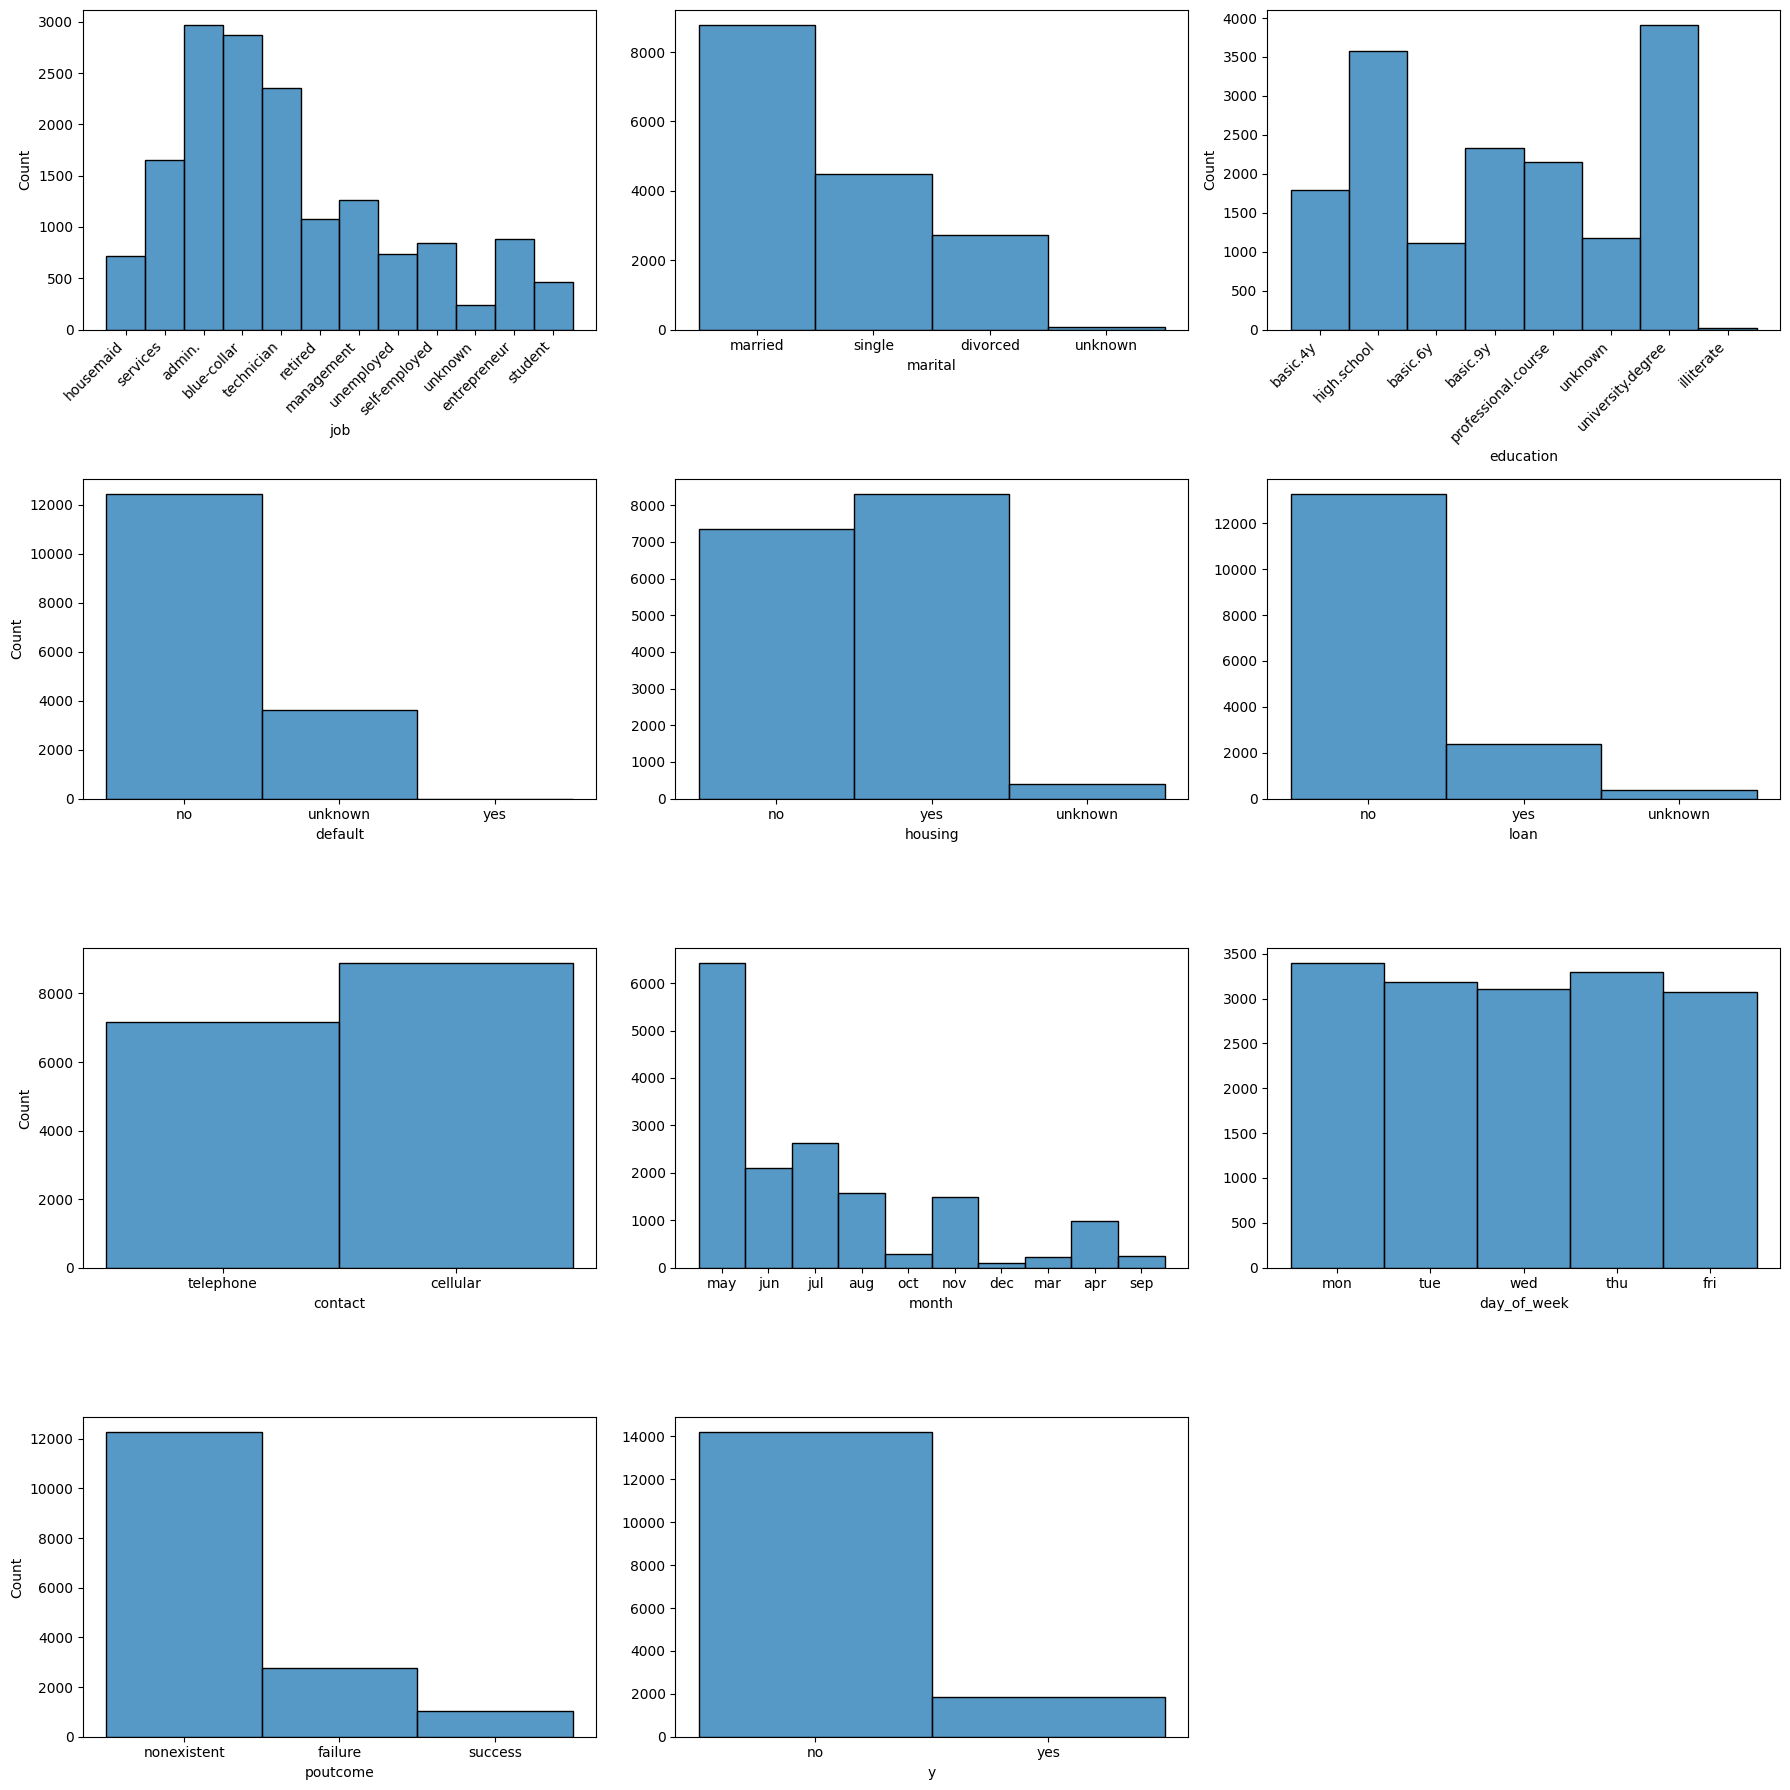

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

#creo la figura con una cuadricula de 4 filas y 3 columnas (12 graficos en total)
#y figsize define el tamaño total de la figura
fig, axis = plt.subplots(4, 3, figsize=(18, 18))

#creo un histograma multiple, cada grafico lo asigno a una cuadricula con el axis[fila,col]
#y en data meto los datos y en x mi variable categorica que vamos a analizar
sns.histplot(ax=axis[0, 0], data=datos_importados_total, x="job").set_xticklabels(axis[0, 0].get_xticklabels(), rotation=45, ha="right")#meto el set_xticklabels porque si no se solapan los trbajos y la education porque hay muchos tipos de trabajo y educacione,que lo que hace es rotar los nombres para que no se solapen
sns.histplot(ax=axis[0, 1], data=datos_importados_total, x="marital").set(ylabel=None)
sns.histplot(ax=axis[0, 2], data=datos_importados_total, x="education").set_xticklabels(axis[0, 2].get_xticklabels(), rotation=45, ha="right")
sns.histplot(ax=axis[1, 0], data=datos_importados_total, x="default")
sns.histplot(ax=axis[1, 1], data=datos_importados_total, x="housing").set(ylabel=None)
sns.histplot(ax=axis[1, 2], data=datos_importados_total, x="loan").set(ylabel=None)
sns.histplot(ax=axis[2, 0], data=datos_importados_total, x="contact")
sns.histplot(ax=axis[2, 1], data=datos_importados_total, x="month").set(ylabel=None)
sns.histplot(ax=axis[2, 2], data=datos_importados_total, x="day_of_week").set(ylabel=None)
sns.histplot(ax=axis[3, 0], data=datos_importados_total, x="poutcome")
sns.histplot(ax=axis[3, 1], data=datos_importados_total, x="y").set(ylabel=None)

#eliminamos el ultimo subplot que queda vacio
fig.delaxes(axis[3, 2])

#ajusto el layout
plt.tight_layout()

#muestro el plot
plt.show()

#### Analisis de variables numericas

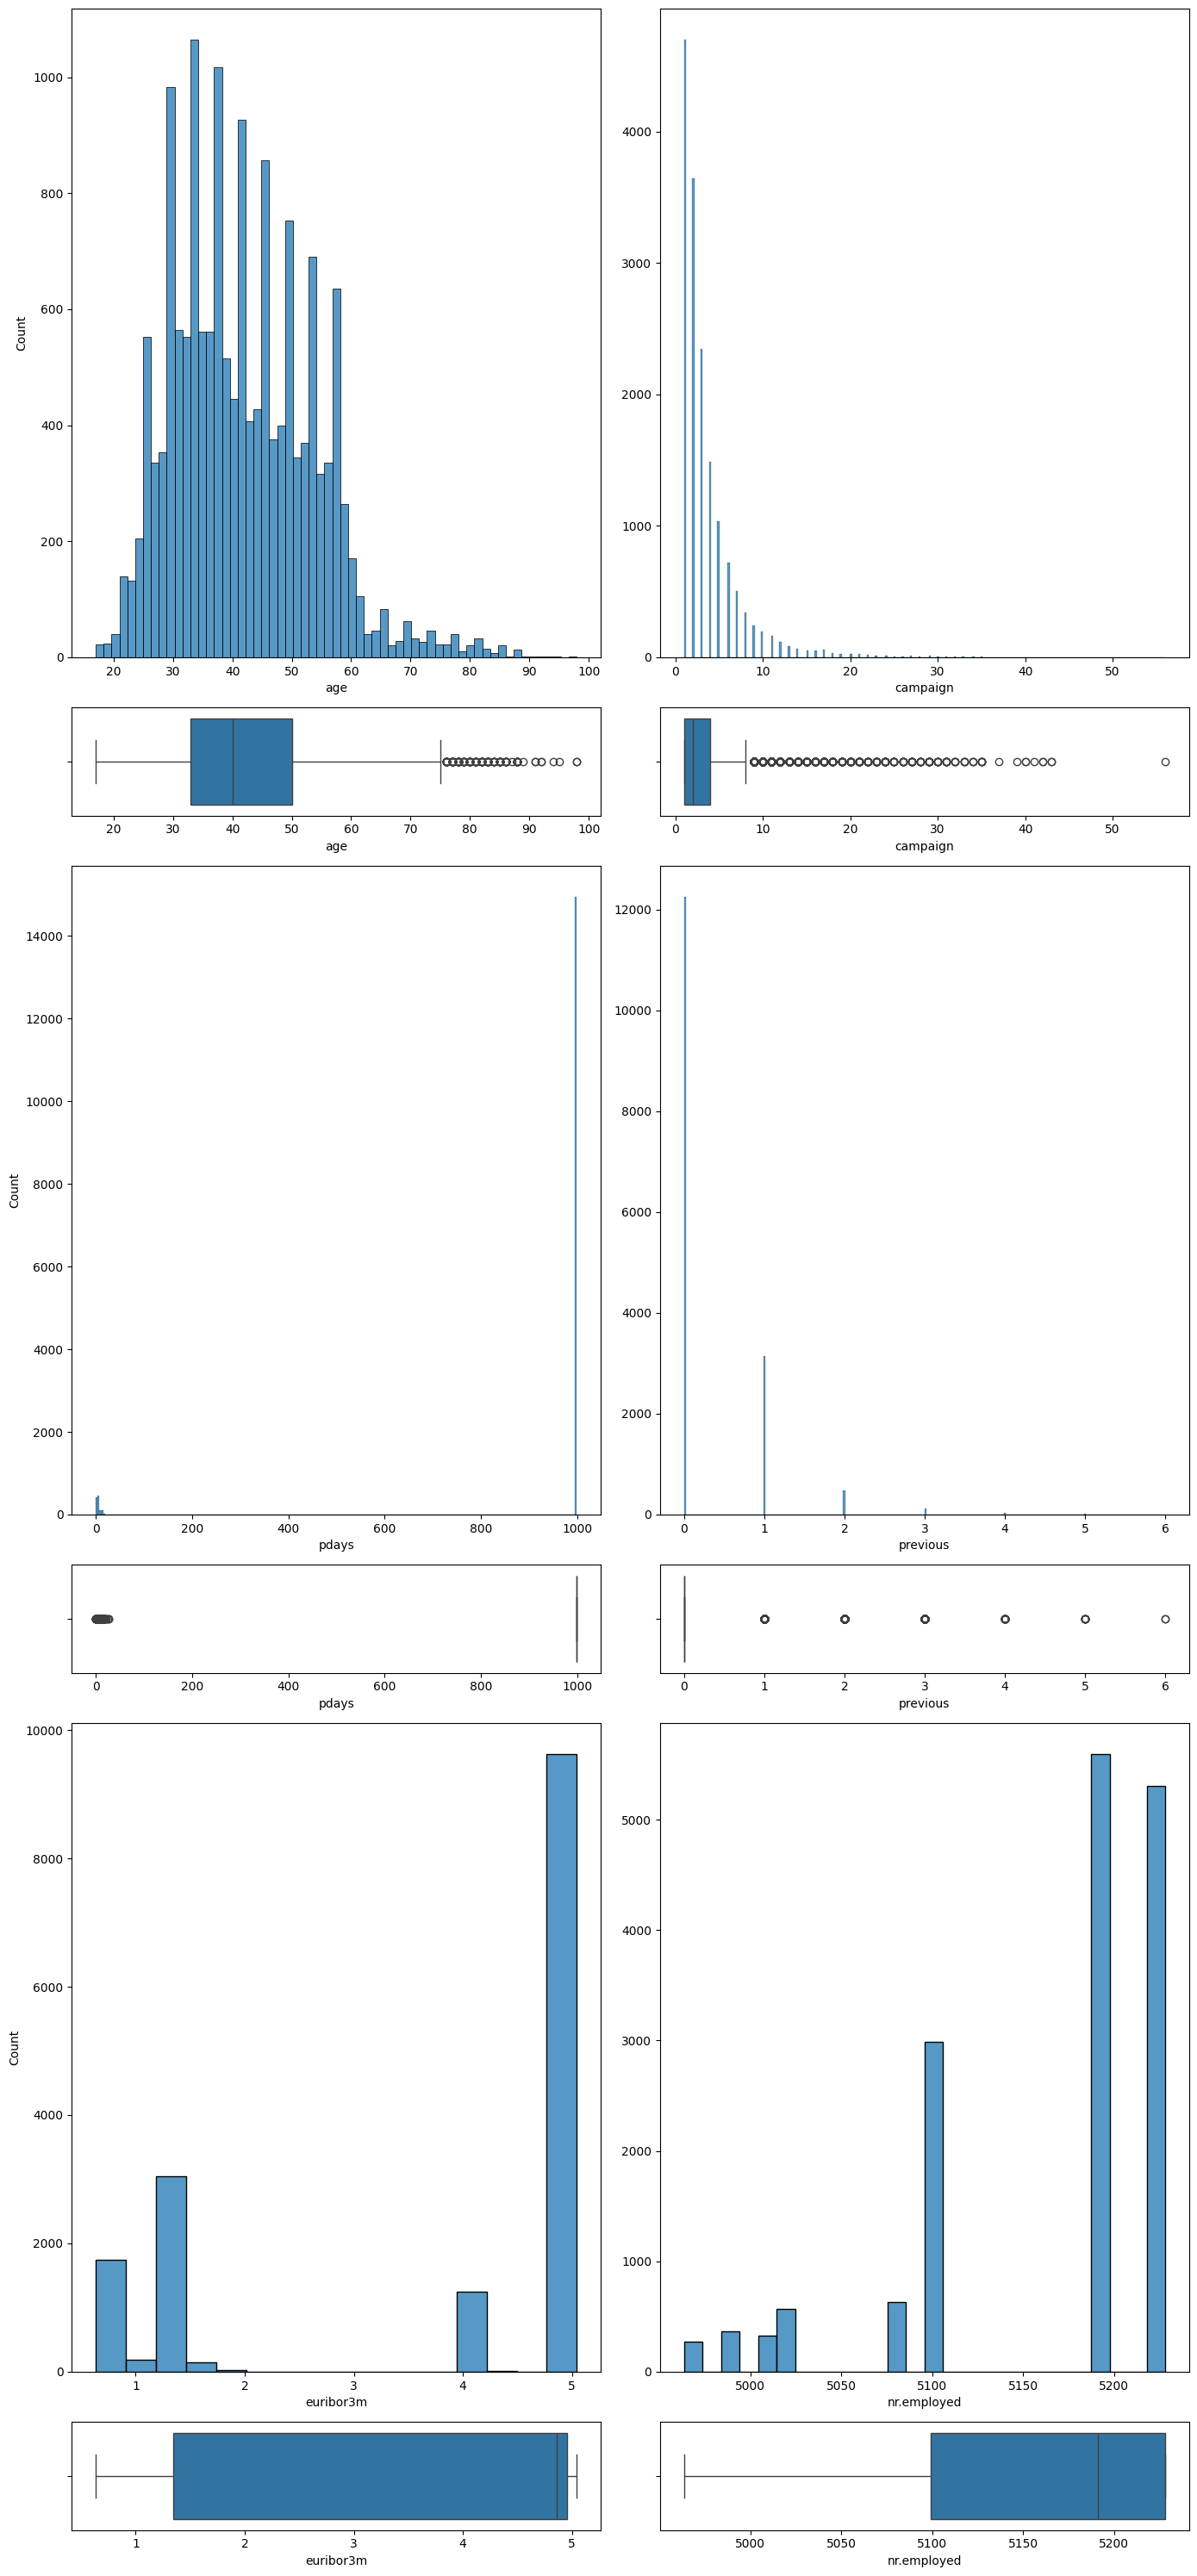

In [12]:
#creo la figura con una cuadricula de 6 filas y 2 columnas (12 graficos en total)
#y gridspec es un argumento para poner que las filas pares son mas altas (histogramas)
#y las impares son mas compactas (boxplots), para ver mejor la distribucion
fig, axis = plt.subplots(6, 2, figsize=(14, 30), gridspec_kw={"height_ratios": [6, 1, 6, 1, 6, 1]})

#columna izquierda: age
#histograma para ver la distribucion de la edad de los clientes
sns.histplot(ax=axis[0, 0], data=datos_importados_total, x="age")
# boxplot para identificar outliers en la edad
sns.boxplot(ax=axis[1, 0], data=datos_importados_total, x="age")

#olumna derecha: campaign
#histograma para ver cuantos contactos se realizaron por cliente en esta campaña
sns.histplot(ax=axis[0, 1], data=datos_importados_total, x="campaign").set(ylabel=None)
#boxplot para identificar clientes contactados un numero anormalmente alto de veces
sns.boxplot(ax=axis[1, 1], data=datos_importados_total, x="campaign")

#columna izquierda: pdays
#histograma para ver cuantos dias pasaron desde el ultimo contacto
#nota: el valor 999 significa que el cliente no fue contactado previamente
sns.histplot(ax=axis[2, 0], data=datos_importados_total, x="pdays")
#boxplot para identificar outliers
sns.boxplot(ax=axis[3, 0], data=datos_importados_total, x="pdays")

#columna derecha: previous
#histograma para ver cuantos contactos hubo en campañas anteriores
sns.histplot(ax=axis[2, 1], data=datos_importados_total, x="previous").set(ylabel=None)
#boxplot para identificar outliers
sns.boxplot(ax=axis[3, 1], data=datos_importados_total, x="previous")

#columna izquierda: euribor3m
#histograma para ver la distribucion de la tasa euribor a 3 meses
sns.histplot(ax=axis[4, 0], data=datos_importados_total, x="euribor3m")
#boxplot para identificar outliers en la tasa euribor
sns.boxplot(ax=axis[5, 0], data=datos_importados_total, x="euribor3m")

#columna derecha: nr.employed
#histograma para ver la distribucion del numero de empleados
sns.histplot(ax=axis[4, 1], data=datos_importados_total, x="nr.employed").set(ylabel=None)
#boxplot para identificar outliers
sns.boxplot(ax=axis[5, 1], data=datos_importados_total, x="nr.employed")

#ajusto el layout
plt.tight_layout()

#muestro el plot
plt.show()

### Paso 4 Analisis de variables multivariadas

####  Analisis numerico-numerico

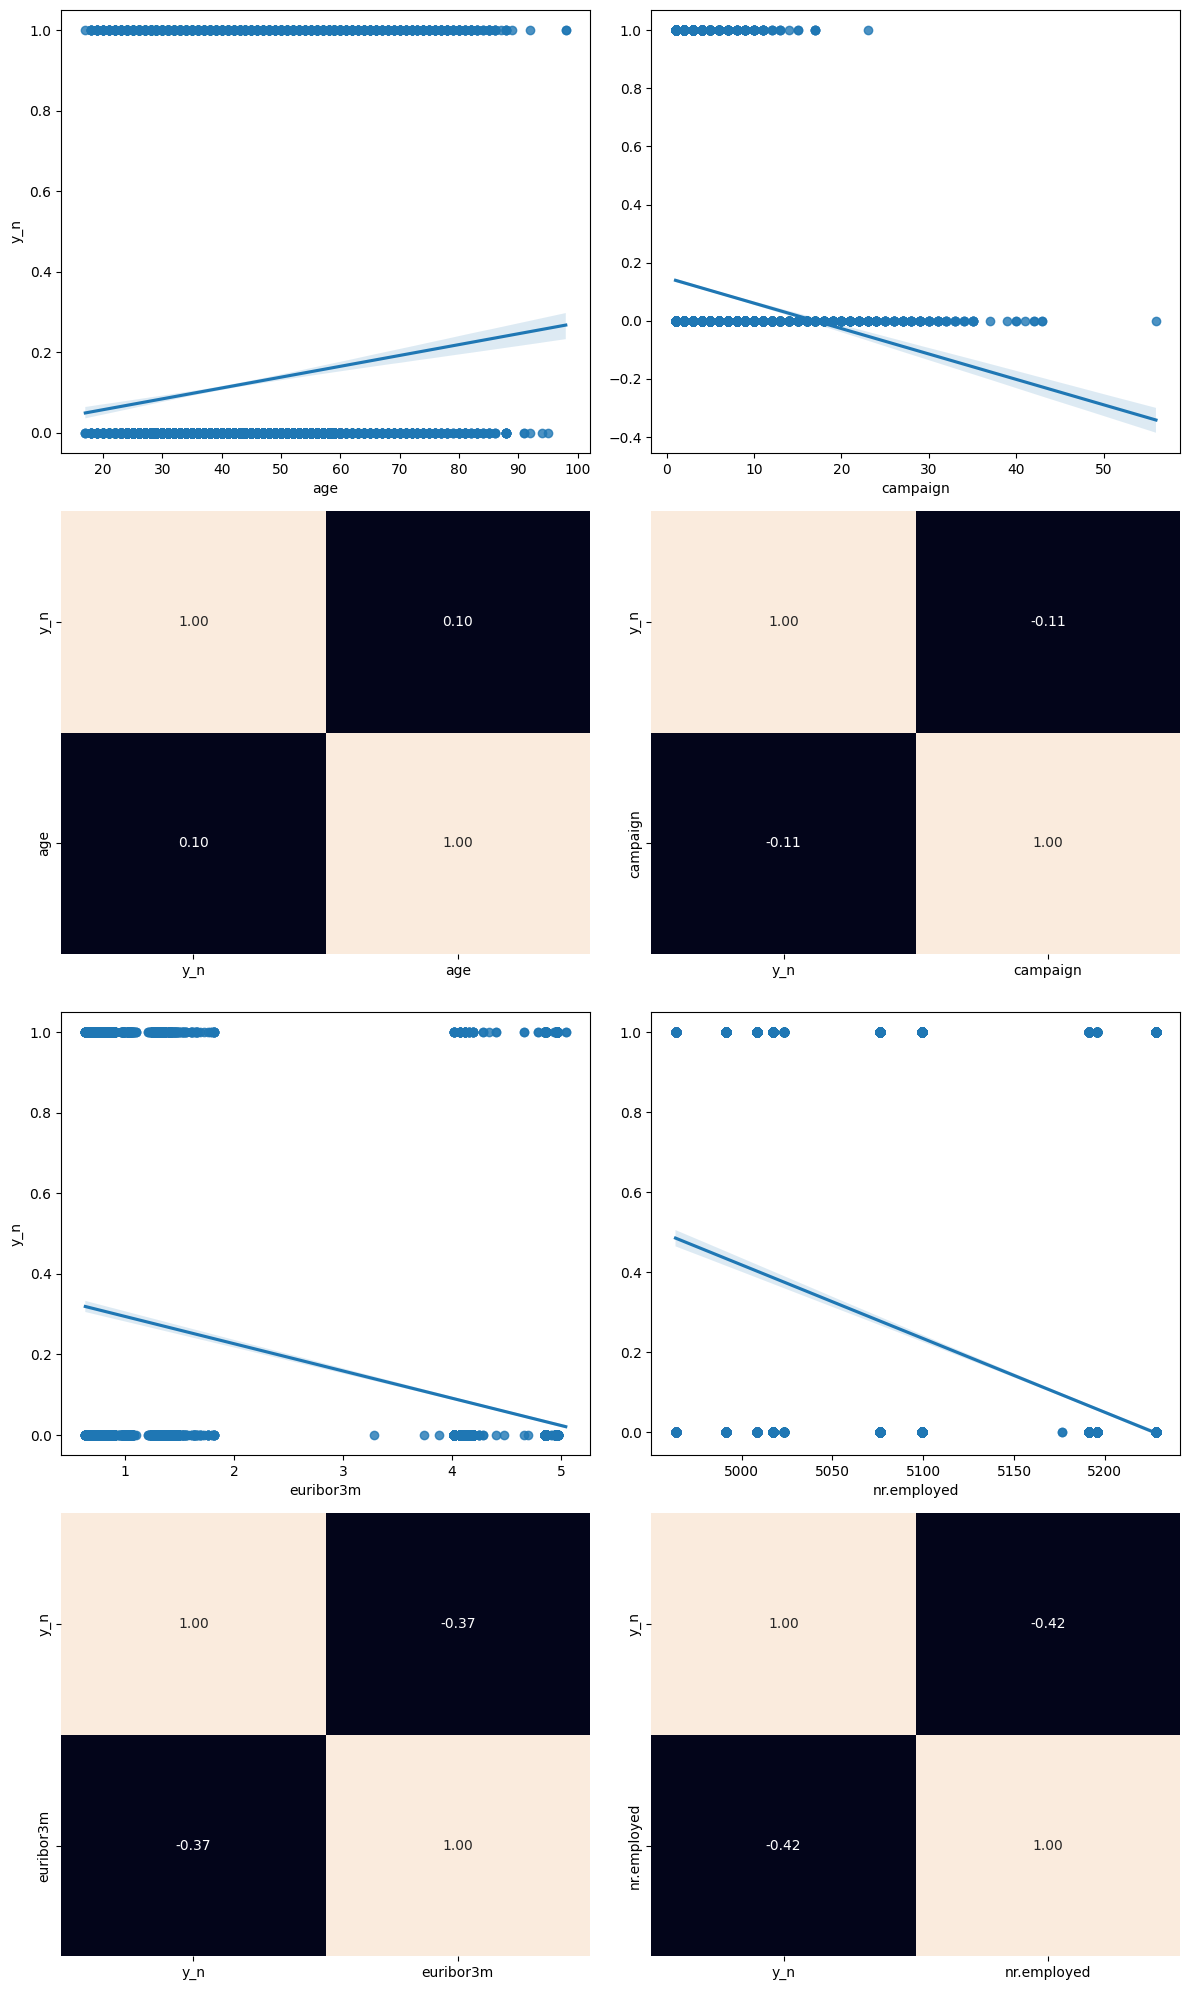

In [13]:
#codifico la variable objetivo y (yes/no) a numerica (1/0)
#para poder usarla en el analisis de correlacion que requiere variables numericas
datos_importados_total["y_n"] = datos_importados_total["y"].map({"yes": 1, "no": 0})

#creo la figura con una cuadricula de 4 filas y 2 columnas para analizar la correlacion
#entre la variable objetivo y_n y las variables numericas mas relevantes
fig, axis = plt.subplots(4, 2, figsize=(12, 20))

#y_n vs age
#grafico de regresion para visualizar la tendencia lineal entre edad y contratacion
sns.regplot(ax=axis[0, 0], data=datos_importados_total, x="age", y="y_n")
#heatmap con el coeficiente de correlacion de ambas variables, annot muestra el valor numerico,
#fmt es para redondear a 2 decimales y cbar es para ocultar la barra de color
sns.heatmap(datos_importados_total[["y_n", "age"]].corr(), annot=True, fmt=".2f", ax=axis[1, 0], cbar=False)

#y_n vs campaign
# grafico de regresion para ver si el numero de contactos influye en la contratacion
sns.regplot(ax=axis[0, 1], data=datos_importados_total, x="campaign", y="y_n").set(ylabel=None)
# heatmap con el coeficiente de correlacion de ambas variables
sns.heatmap(datos_importados_total[["y_n", "campaign"]].corr(), annot=True, fmt=".2f", ax=axis[1, 1], cbar=False)

#y_n vs euribor3m
#grafico de regresion para ver si la tasa euribor influye en la contratacion
sns.regplot(ax=axis[2, 0], data=datos_importados_total, x="euribor3m", y="y_n")
# heatmap con el coeficiente de correlacion de ambas variables
sns.heatmap(datos_importados_total[["y_n", "euribor3m"]].corr(), annot=True, fmt=".2f", ax=axis[3, 0], cbar=False)

#y_n vs nr.employed
#grafico de regresion para ver si el numero de empleados influye en la contratacion
sns.regplot(ax=axis[2, 1], data=datos_importados_total, x="nr.employed", y="y_n").set(ylabel=None)
#heatmap con el coeficiente de correlacion de ambas variables
sns.heatmap(datos_importados_total[["y_n", "nr.employed"]].corr(), annot=True, fmt=".2f", ax=axis[3, 1], cbar=False)

#ajusto el layout
plt.tight_layout()

#muestro el plot
plt.show()

####  Analisis categorico-categorico

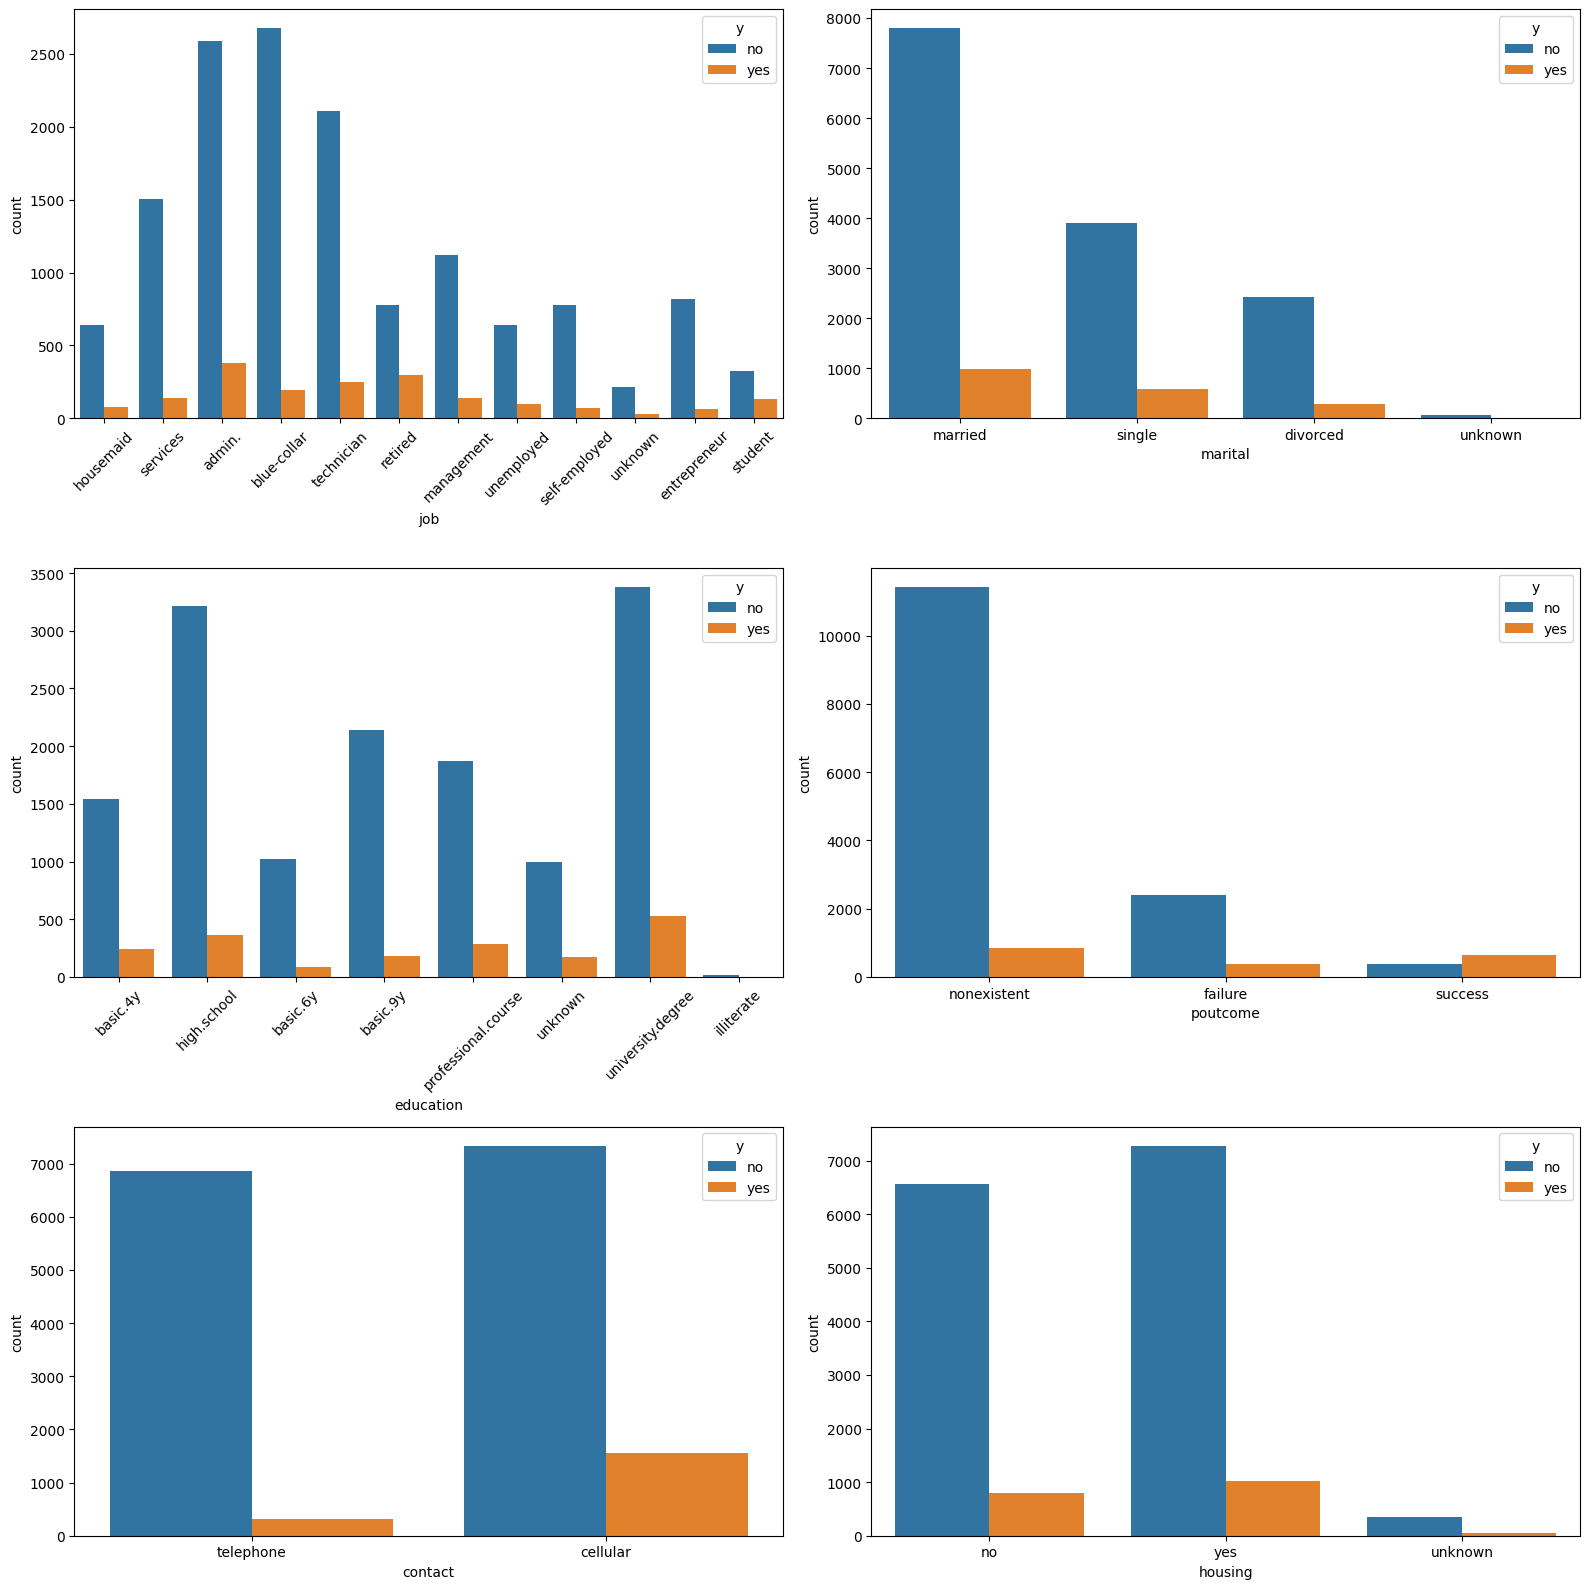

In [15]:
#creo una figura con cuadricula de 3x2 para ver la relacion entre
#las variables categoricas mas importantes y la variable objetivo y
fig, axis = plt.subplots(3, 2, figsize=(16, 16))

#grafico de barras que muestra cuantos clientes contrataron (y) segun el tipo de trabajo
sns.countplot(ax=axis[0, 0], data=datos_importados_total, x="job", hue="y")
axis[0, 0].tick_params(axis="x", rotation=45)

#grafico de barras que muestra la contratacion segun el estado civil
sns.countplot(ax=axis[0, 1], data=datos_importados_total, x="marital", hue="y")

# grafico de barras que muestra la contratacion segun el nivel de educacion
sns.countplot(ax=axis[1, 0], data=datos_importados_total, x="education", hue="y")
axis[1, 0].tick_params(axis="x", rotation=45)

#grafico de barras que muestra la contratacion segun el resultado de campañas anteriores
sns.countplot(ax=axis[1, 1], data=datos_importados_total, x="poutcome", hue="y")

#grafico de barras que muestra la contratacion segun el tipo de contacto
sns.countplot(ax=axis[2, 0], data=datos_importados_total, x="contact", hue="y")

#grafico de barras que muestra la contratacion segun si tiene prestamo de vivienda
sns.countplot(ax=axis[2, 1], data=datos_importados_total, x="housing", hue="y")

#ajusto el layout
plt.tight_layout()

#muestro el plot
plt.show()

#### Analisis numerico-categorico (completo)

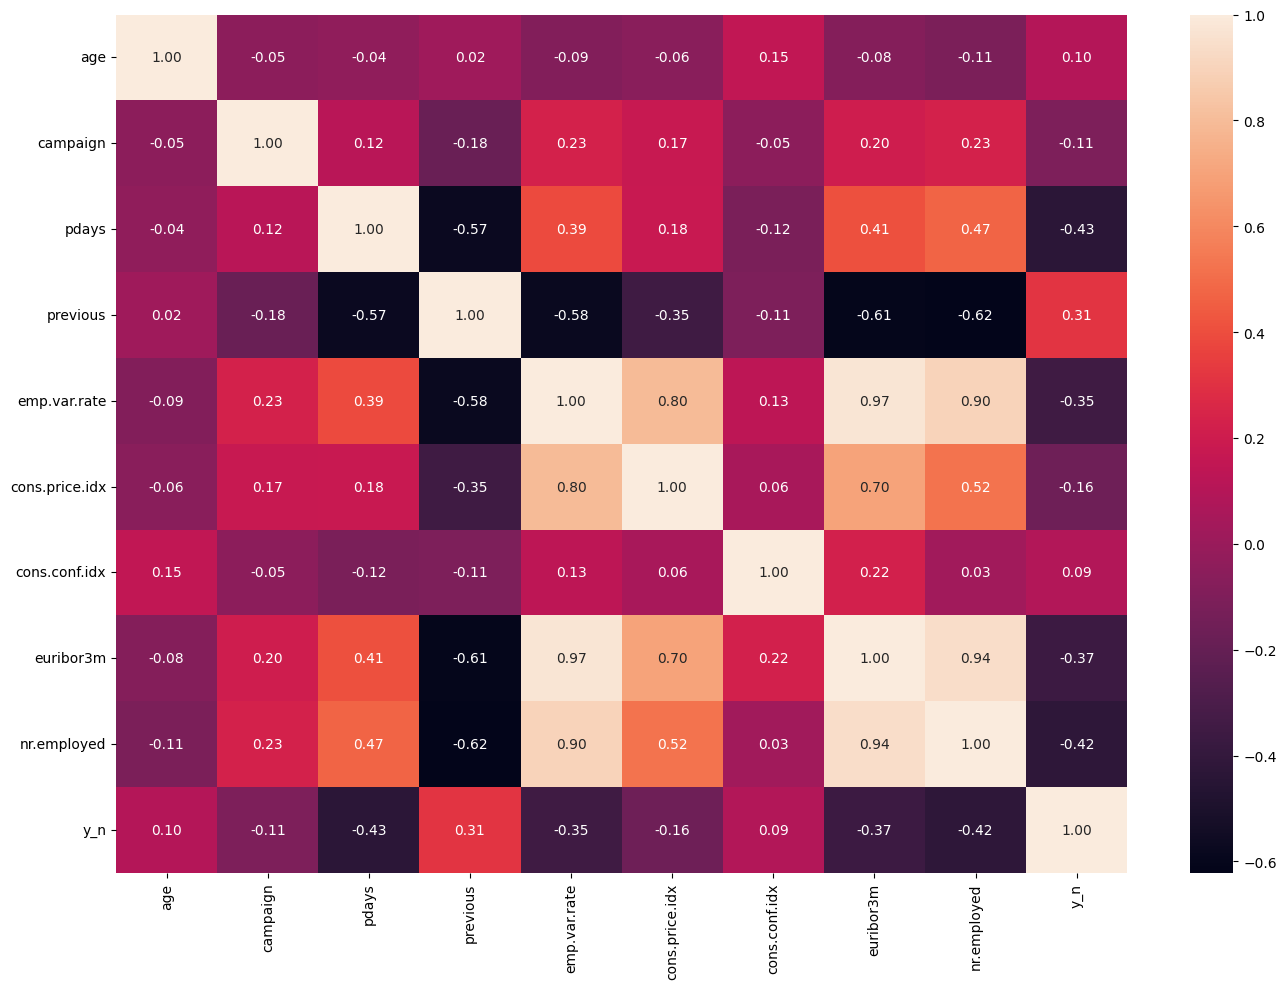

In [16]:
#aplicamos one hot encoding directamente sobre las columnas categoricas originales
variables_one = pd.get_dummies(
    datos_importados_total[[
        "job", "marital", "education", "default",
        "housing", "loan", "contact", "month",
        "day_of_week", "poutcome"
    ]],
    drop_first=True  #eliminamos la primera categoria de cada variable para evitar multicolinealidad
)

#columnas numericas que queremos conservar junto con las dummies
cols_numericas = [
    "age", "campaign", "pdays", "previous", "emp.var.rate",
    "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed", "y_n"
]

#unimos las columnas numericas con las dummies generadas
datos_importados_total = pd.concat([datos_importados_total[cols_numericas], variables_one], axis=1)

#para el heatmap usamos solo las numericas originales para que sea legible
#pintar todas las dummies lo haria ilegible
fig, axes = plt.subplots(figsize=(14, 10))
sns.heatmap(datos_importados_total[cols_numericas].corr(), annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

#### Analizazndo todos los datos a la vez

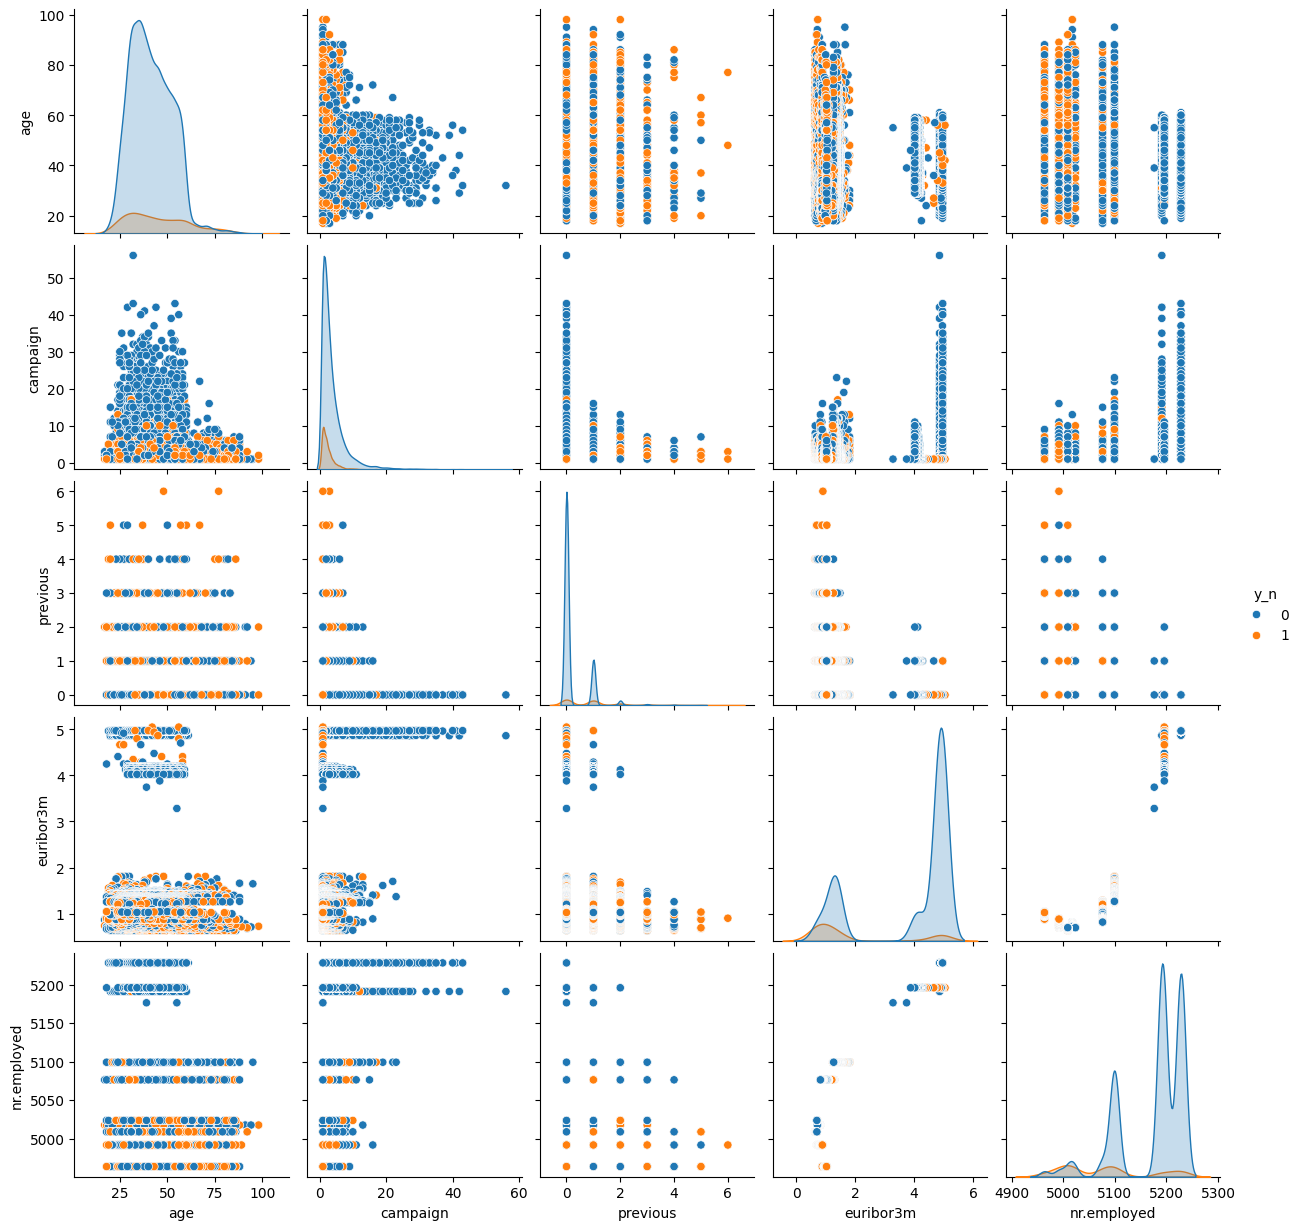

In [17]:
#genero un pairplot que muestra la relacion entre todas las variables numericas
#del dataframe, asi se ven facilmente patrones u outliers
cols_pairplot = ["age", "campaign", "previous", "euribor3m", "nr.employed", "y_n"]
sns.pairplot(data=datos_importados_total[cols_pairplot], hue="y_n")
plt.show()

### Paso 5: Ingenieria de caracteristicas

In [18]:
#genero un resumen estadistico descriptivo de todas las variables numericas del dataframe
datos_importados_total.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_n
count,16049.000000,16049.000000,16049.000000,16049.000000,16049.000000,16049.000000,16049.000000,16049.000000,16049.000000,16049.000000
mean,41.841859,3.642906,930.986604,0.292542,0.089476,93.630808,-40.171543,3.635434,5163.832631,0.116082
std,11.723054,3.886992,250.860899,0.598557,1.563367,0.587980,4.641216,1.738946,72.913380,0.320333
min,17.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,33.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,40.000000,2.000000,999.000000,0.000000,1.100000,93.918000,-41.800000,4.857000,5191.000000,0.000000
75%,50.000000,4.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.959000,5228.100000,0.000000
max,98.000000,56.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


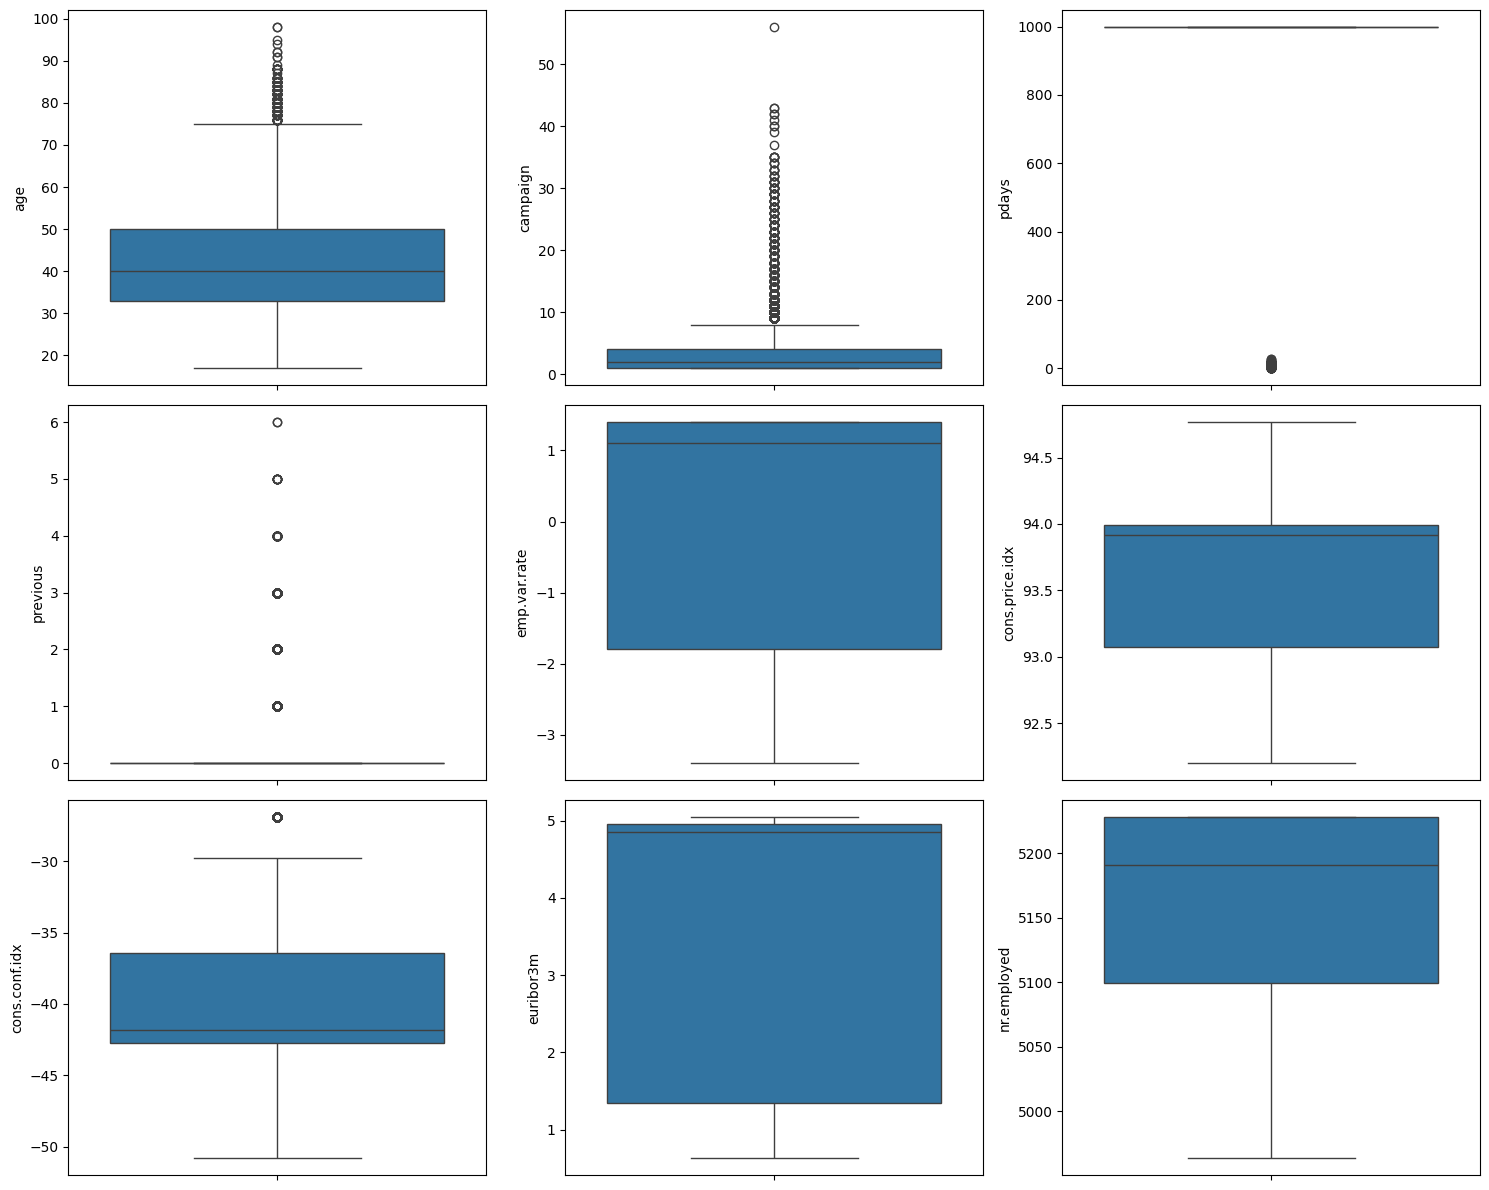

In [19]:
#creo una figura con cuadricula de 3x3 (9 boxplots en total) para analizar la distribucion
#y outliers de las variables numericas del dataframe
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

sns.boxplot(ax=axes[0, 0], data=datos_importados_total, y="age")
sns.boxplot(ax=axes[0, 1], data=datos_importados_total, y="campaign")
sns.boxplot(ax=axes[0, 2], data=datos_importados_total, y="pdays")
sns.boxplot(ax=axes[1, 0], data=datos_importados_total, y="previous")
sns.boxplot(ax=axes[1, 1], data=datos_importados_total, y="emp.var.rate")
sns.boxplot(ax=axes[1, 2], data=datos_importados_total, y="cons.price.idx")
sns.boxplot(ax=axes[2, 0], data=datos_importados_total, y="cons.conf.idx")
sns.boxplot(ax=axes[2, 1], data=datos_importados_total, y="euribor3m")
sns.boxplot(ax=axes[2, 2], data=datos_importados_total, y="nr.employed")

#ajusto el layout
plt.tight_layout()

#muestro la figura
plt.show()

##### Deteccion de outliers para price

In [20]:
#sacamos solo el resumen estadistico descriptivo de campaign para trabajar con ellos
datos_campaign = datos_importados_total["campaign"].describe()
datos_campaign

count    16049.000000
mean         3.642906
std          3.886992
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         56.000000
Name: campaign, dtype: float64

In [21]:
#calculo el rango intercuartilico de la variable campaign (50% de los datos)
iqr_campaign = datos_campaign["75%"] - datos_campaign["25%"]

#calculo el limite superior, porque valores por encima de este valor se consideran outliers
upper_limit = datos_campaign["75%"] + 1.5 * iqr_campaign

#calculo el limite inferior, porque valores por debajo de este valor se consideran outliers
lower_limit = datos_campaign["25%"] - 1.5 * iqr_campaign

#lo imprimo
print(f"los limites superiores e inferiores de campaign son {round(upper_limit, 2)} y {round(lower_limit, 2)}, con un rango intercuartil de {round(iqr_campaign, 2)}")

los limites superiores e inferiores de campaign son 8.5 y -3.5, con un rango intercuartil de 3.0


In [22]:
#filtro los registros eliminando outliers en campaign,
#solo cogiendo clientes que hayan sido contactados un maximo de veces igual al limite superior
total_data = datos_importados_total[datos_importados_total["campaign"] <= upper_limit]

#cuento los clientes que han sido contactados 1, 2, 3, 4 o 5 veces
#para analizar la distribucion de los valores mas frecuentes
count_1 = total_data[total_data["campaign"] == 1].shape[0]
count_2 = total_data[total_data["campaign"] == 2].shape[0]
count_3 = total_data[total_data["campaign"] == 3].shape[0]
count_4 = total_data[total_data["campaign"] == 4].shape[0]
count_5 = total_data[total_data["campaign"] == 5].shape[0]

#se imprimen los contadores de cada numero de contactos
print("contador de 1: ", count_1)
print("contador de 2: ", count_2)
print("contador de 3: ", count_3)
print("contador de 4: ", count_4)
print("contador de 5: ", count_5)

contador de 1:  4699
contador de 2:  3645
contador de 3:  2347
contador de 4:  1490
contador de 5:  1033


#### Analisis de valores faltantes

In [23]:
#mostramos las columnas que tienen nulos y los ordenamos de manera descendente
total_data.isnull().sum().sort_values(ascending=False)

age                              0
campaign                         0
pdays                            0
previous                         0
emp.var.rate                     0
cons.price.idx                   0
cons.conf.idx                    0
euribor3m                        0
nr.employed                      0
y_n                              0
job_blue-collar                  0
job_entrepreneur                 0
job_housemaid                    0
job_management                   0
job_retired                      0
job_self-employed                0
job_services                     0
job_student                      0
job_technician                   0
job_unemployed                   0
job_unknown                      0
marital_married                  0
marital_single                   0
marital_unknown                  0
education_basic.6y               0
education_basic.9y               0
education_high.school            0
education_illiterate             0
education_profession

#### Escalado de caracteristicas

In [26]:
from sklearn.preprocessing import MinMaxScaler

#columnas numericas que vamos a escalar
#se excluye y_n al ser la variable objetivo (no debe escalarse)
columnas_numericas = [
    "age", "campaign", "pdays", "previous", "emp.var.rate",
    "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"
]

#creamos el escalador, que transforma cada variable al rango [0,1]
escalador = MinMaxScaler()

#aplicar escalado
variables_escaladas = escalador.fit_transform(total_data[columnas_numericas])

#convertimos a dataframe para mantener la estructura
datos_escalados = pd.DataFrame(variables_escaladas, index=total_data.index, columns=columnas_numericas)

#añadimos la variable objetivo (y_n)
datos_escalados["y_n"] = total_data["y_n"].values

#lo mostramos
datos_escalados.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y_n
0,0.481481,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0
1,0.493827,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0
2,0.246914,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0
3,0.283951,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0
4,0.481481,0.0,1.0,0.0,0.9375,0.698753,0.60251,0.957379,0.859735,0


### Paso 6: seleccion de caracteristicas

In [27]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split

#separamos variables predictoras y objetivo
X = datos_escalados.drop("y_n", axis=1)
y = datos_escalados["y_n"]

#dividimos los datos en train y test antes de la seleccion de caracteristicas
#ara evitar contaminacion de datos (data leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#seleccionamos las 10 mejores variables usando f_classif
#usamos f_classif porque nuestra variable objetivo es binaria (clasificacion)
selector = SelectKBest(f_classif, k=10)

#entrenamos el selector solo con los datos de entrenamiento
selector.fit(X_train, y_train)

#obtenemos las columnas seleccionadas
columnas_seleccionadas = selector.get_support()

#aplicamos la seleccion a train y test
X_train_sel = pd.DataFrame(selector.transform(X_train), columns=X_train.columns.values[columnas_seleccionadas])
X_test_sel  = pd.DataFrame(selector.transform(X_test),  columns=X_test.columns.values[columnas_seleccionadas])

#sacamos el resultado
print("caracteristicas seleccionadas:", list(X_train.columns.values[columnas_seleccionadas]))
X_train_sel.head()

caracteristicas seleccionadas: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


c:\Users\Marcos\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:782: UserWarning: k=10 is greater than n_features=9. All the features will be returned.
  warnings.warn(


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,0.259259,0.285714,1.0,0.0,0.333333,0.340608,0.154812,0.174790,0.512287
1,0.172840,0.000000,1.0,0.0,1.000000,0.484412,0.615063,0.982317,1.000000
2,0.333333,0.000000,1.0,0.0,0.937500,0.698753,0.602510,0.957379,0.859735
3,0.160494,0.000000,1.0,0.0,0.937500,0.698753,0.602510,0.957379,0.859735
4,0.185185,0.142857,1.0,0.0,0.333333,0.340608,0.154812,0.165722,0.512287


####  Guardamos los datos limpios


In [28]:
#se añade la variable objetivo y_n a los conjuntos de prueba y entrenamiento
X_train_sel["y"] = list(y_train)
X_test_sel["y"]  = list(y_test)

#se exportan los conjuntos de datos procesados a archivos CSV
X_train_sel.to_csv("../data/processed/train.csv", index=False)
X_test_sel.to_csv("../data/processed/test.csv", index=False)

### Paso 7: Modelo de Regresión Logística

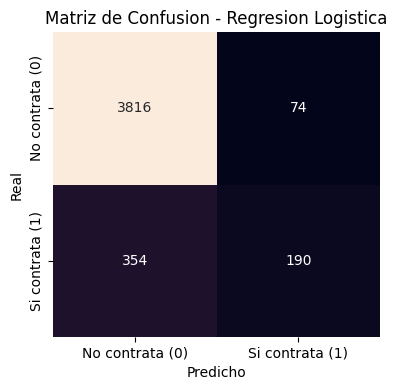

In [29]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

#leemos los datos procesados
train_data = pd.read_csv("../data/processed/train.csv")
test_data  = pd.read_csv("../data/processed/test.csv")

#separamos las variables predictoras de la variable objetivo en train y test
X_train = train_data.drop(["y"], axis=1)
y_train = train_data["y"]

X_test = test_data.drop(["y"], axis=1)
y_test = test_data["y"]


#inicializamos el modelo con los parametros por defecto
model = LogisticRegression()

#entrenamos el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

#realizamos predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test)
y_pred


#evaluamos el modelo con el accuracy: porcentaje de predicciones correctas
accuracy_score(y_test, y_pred)

#construimos la matriz de confusion para ver los aciertos y errores por clase
bank_cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(bank_cm)

plt.figure(figsize=(4, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False,
            xticklabels=["No contrata (0)", "Si contrata (1)"],
            yticklabels=["No contrata (0)", "Si contrata (1)"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusion - Regresion Logistica")
plt.tight_layout()
plt.show()